# Eigenvalues and Eigenvectors

*Course notes for **Math for Machine Learning**, C1 · W4 · L2 · V04a — "Eigenvalues and Eigenvectors" (DeepLearning.AI).*

A closer look at *why* eigenvalues and eigenvectors are special. Using the same matrix $A = \begin{pmatrix} 2 & 1 \\ 0 & 3 \end{pmatrix}$, we make the idea precise and turn it into a genuine computational shortcut. We cover:

- The defining equation $A v = \lambda v$ (eigenvector vs. non-eigenvector).
- Why it **saves work**: matrix multiplication $\to$ scalar multiplication.
- Applying the shortcut to **any** vector via the **eigenbasis**, and the catch (**diagonalization**).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

A = np.array([[2, 1],
              [0, 3]])

## 1. Eigenvector or not? Test with $A v$

Multiply $A$ by three vectors and check whether the result **still points the same way**:

| $v$ | $A v$ | eigenvector? |
|---|---|---|
| $(1,0)$ | $(2,0) = 2\,(1,0)$ | **yes**, $\lambda = 2$ |
| $(1,1)$ | $(3,3) = 3\,(1,1)$ | **yes**, $\lambda = 3$ |
| $(-1,2)$ | $(0,6)$ | **no** — no scalar $\lambda$ works |

An **eigenvector** is a direction the matrix merely **scales**; $(-1,2)$ gets rotated to a new direction, so it isn't one.

In [2]:
def eigen_report(v):
    Av = A @ v
    # is Av a scalar multiple of v?  (parallel via zero cross product)
    parallel = np.isclose(v[0]*Av[1] - v[1]*Av[0], 0)
    lam = Av[np.argmax(np.abs(v))] / v[np.argmax(np.abs(v))] if parallel else None
    return Av, parallel, lam

for v in [np.array([1, 0]), np.array([1, 1]), np.array([-1, 2])]:
    Av, is_eig, lam = eigen_report(v)
    tag = f'eigenvector, lambda = {lam:.0f}' if is_eig else 'NOT an eigenvector'
    print(f'A @ {v} = {Av}   -> {tag}')

A @ [1 0] = [2 0]   -> eigenvector, lambda = 2
A @ [1 1] = [3 3]   -> eigenvector, lambda = 3
A @ [-1  2] = [0 6]   -> NOT an eigenvector


## 2. The defining equation $A v = \lambda v$

Formally, an **eigenvector** $v$ with **eigenvalue** $\lambda$ satisfies

$$ A v = \lambda v. $$

Here $A v_1 = \lambda_1 v_1$ with $v_1 = (1,0),\, \lambda_1 = 2$, and $A v_2 = \lambda_2 v_2$ with $v_2 = (1,1),\, \lambda_2 = 3$. Eigenvectors and eigenvalues always come in **pairs**: $(v_1, \lambda_1)$ and $(v_2, \lambda_2)$.

In [3]:
eigvals, eigvecs = np.linalg.eig(A)
print('eigenvalues :', eigvals)
print('eigenvectors (columns):')
print(eigvecs)
for i in range(2):
    v, lam = eigvecs[:, i], eigvals[i]
    print(f'A v = {A @ v}   lambda v = {lam * v}   (equal)')

eigenvalues : [2. 3.]
eigenvectors (columns):
[[1.    0.707]
 [0.    0.707]]
A v = [2. 0.]   lambda v = [2. 0.]   (equal)
A v = [2.121 2.121]   lambda v = [2.121 2.121]   (equal)


## 3. Why special: matrix multiply $\to$ scalar multiply

The left side $A v$ is a **matrix multiplication**; the right side $\lambda v$ is a **scalar multiplication** — far less work. For an $n \times n$ matrix, $A v$ costs about $n^2$ multiplications while $\lambda v$ costs only $n$. For $n$ in the hundreds or thousands, that gap is enormous.

> Along an eigenvector, a large computation collapses into a tiny one.

     n    A v (n^2)   lambda v (n)    speedup
     2            4              2         2x
    10          100             10        10x
   100        10000            100       100x
  1000      1000000           1000      1000x


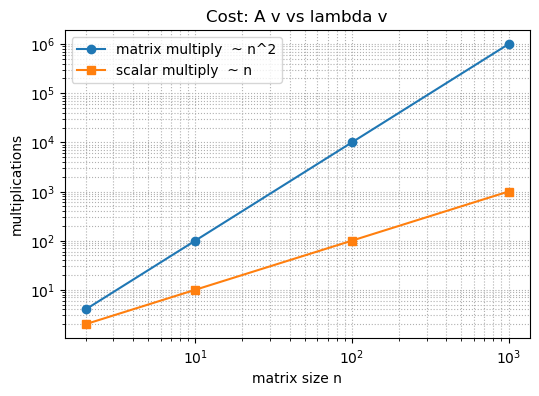

In [4]:
# multiplication counts: A v (~n^2) vs lambda v (~n)
ns = np.array([2, 10, 100, 1000])
print(f'{"n":>6} {"A v (n^2)":>12} {"lambda v (n)":>14} {"speedup":>10}')
for n in ns:
    print(f'{n:>6} {n*n:>12} {n:>14} {n:>9}x')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ns, ns**2, 'o-', label='matrix multiply  ~ n^2')
ax.plot(ns, ns, 's-', label='scalar multiply  ~ n')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('matrix size n'); ax.set_ylabel('multiplications')
ax.grid(True, ls=':', which='both'); ax.legend()
ax.set_title('Cost: A v vs lambda v')
plt.show()

## 4. Applying the shortcut to *any* vector

The eigenvectors $(1,0)$ and $(1,1)$ are linearly independent and span the plane — they form the **eigenbasis**. So even a non-eigenvector like $(-1,2)$ can ride the shortcut. Write it in the eigenbasis:

$$ (-1, 2) = -3\,(1,0) + 2\,(1,1). $$

Now apply $A$, pushing it through the linear combination and replacing each $A v_i$ by $\lambda_i v_i$:

$$ A(-1,2) = -3\,\underbrace{A(1,0)}_{2(1,0)} + 2\,\underbrace{A(1,1)}_{3(1,1)} = -3\cdot 2\,(1,0) + 2\cdot 3\,(1,1) = (0, 6). $$

Same answer as the direct matrix multiply — but reached with **only scalar multiplications**.

In [5]:
v1, v2 = np.array([1, 0]), np.array([1, 1])
p = np.array([-1, 2])

# coordinates of p in the eigenbasis
c1, c2 = np.linalg.solve(np.column_stack([v1, v2]), p)
print('p in eigenbasis: c1 =', c1, ' c2 =', c2)

# apply A using only scalars (eigenvalues 2 and 3)
image = c1 * 2 * v1 + c2 * 3 * v2
print('via scalars only : A @ p =', image)
print('direct matmul    : A @ p =', A @ p, ' (same)')

p in eigenbasis: c1 = -3.0  c2 = 2.0
via scalars only : A @ p = [0. 6.]
direct matmul    : A @ p = [0 6]  (same)


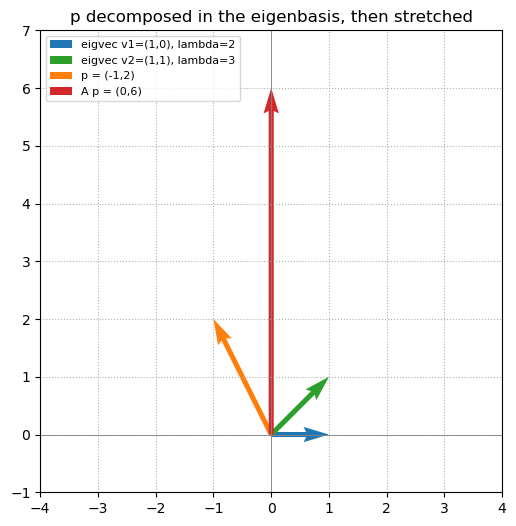

In [6]:
# Visualize the decomposition and its image
fig, ax = plt.subplots(figsize=(6, 6))
opts = dict(angles='xy', scale_units='xy', scale=1, width=0.011)
ax.quiver(0, 0, *v1, color='C0', **opts, label='eigvec v1=(1,0), lambda=2')
ax.quiver(0, 0, *v2, color='C2', **opts, label='eigvec v2=(1,1), lambda=3')
ax.quiver(0, 0, *p, color='C1', **opts, label='p = (-1,2)')
ax.quiver(0, 0, *(A @ p), color='C3', **opts, label='A p = (0,6)')
ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.legend(loc='upper left', fontsize=8)
ax.set_xlim(-4, 4); ax.set_ylim(-1, 7)
ax.set_title('p decomposed in the eigenbasis, then stretched')
plt.show()

## 5. The catch: getting the coordinates (diagonalization)

Finding a vector's eigenbasis coordinates isn't free — in general you multiply by the **inverse of the eigenbasis matrix** $P$ (whose columns are the eigenvectors). Collecting everything gives the **diagonalization**

$$ A = P\,D\,P^{-1}, \qquad P = [\,v_1 \;\; v_2\,], \quad D = \begin{pmatrix} \lambda_1 & 0 \\ 0 & \lambda_2 \end{pmatrix}. $$

Reading right to left: $P^{-1}$ converts to eigen-coordinates, $D$ stretches (cheap!), $P$ converts back. So eigenvectors don't *remove* the work — they let you **decide when to do it**: precompute $P^{-1}$ once, then every transform is just the diagonal $D$. That's exactly the kind of speedup exploited in ML methods like PCA.

In [7]:
P = eigvecs                    # eigenvectors in columns
D = np.diag(eigvals)           # eigenvalues on the diagonal
reconstructed = P @ D @ np.linalg.inv(P)
print('P D P^-1 =')
print(reconstructed)
print('equals A:', np.allclose(reconstructed, A))

P D P^-1 =
[[2. 1.]
 [0. 3.]]
equals A: True


## Summary

- Eigenvectors/eigenvalues are defined by **$A v = \lambda v$** and come in **pairs**; an eigenvector is a direction the matrix only **stretches** (by its eigenvalue).
- Along an eigenvector, an expensive **matrix multiply** ($\sim n^2$) becomes a cheap **scalar multiply** ($\sim n$).
- Because the eigenvectors form the **eigenbasis**, you can apply the shortcut to *any* vector: decompose in the eigenbasis, scale each component by its eigenvalue.
- Getting eigen-coordinates costs a multiply by $P^{-1}$, giving the **diagonalization** $A = P D P^{-1}$ — eigenvectors let you **decide when to do the work** (precompute once, transform cheaply forever after).